# Phase 2.5: Exploratory Data Analysis
## Tiller digital point-of-sale (POS)

**Project:** Tiller digital point-of-sale (POS)  
**BigQuery:** `le-wagon-da-502302.tiller`  
**Date:** September 2026

---

## Objective

This exploratory analysis examines how business activity behaves across **stores, time, transactions, products, payments and operational dimensions**.

**Goal:** Identify meaningful patterns to determine which areas could support deeper investigation in Phase 3 — not to answer final business questions at this stage.

### Structure

1. **Store-level behaviour** — How do stores differ in volume and value?
2. **Temporal behaviour** — How does activity vary over time?
3. **Product and category behaviour** — What products drive value?
4. **Transaction and customer economics** — What drives order value?
5. **Payment and operational behaviour** — How are transactions paid for?

---
## Setup

In [ ]:
import subprocess
from io import StringIO
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

# Professional styling
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['grid.color'] = '#dddddd'
plt.rcParams['grid.linestyle'] = '-'
plt.rcParams['grid.linewidth'] = 0.3
plt.rcParams['text.color'] = '#333333'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

CHARTS_DIR = Path("charts")
CHARTS_DIR.mkdir(exist_ok=True)

def run_query(query):
    result = subprocess.run(
        ["bq", "query", "--use_legacy_sql=false", "--format=csv", query],
        capture_output=True,
        text=True,
    )
    if result.returncode != 0:
        raise RuntimeError(f"Query failed: {result.stderr}")
    return pd.read_csv(StringIO(result.stdout))

def save_and_show(fig, filename):
    plt.tight_layout()
    plt.savefig(CHARTS_DIR / filename, dpi=300, bbox_inches="tight", facecolor='white')
    plt.show()
    plt.close(fig)
    print(f"  ✓ Saved: charts/{filename}")

---
## 2.5.1 Store-level Behaviour

### Context

The dataset contains **21 stores** with substantial heterogeneity. Store 4151 alone represents **~68% of all orders** but has a much lower average order value than most other stores.

### Key Questions

- Which stores have the highest order volume?
- How does average order value vary between stores?
- Is there a relationship between volume and value?

### Why This Matters

Aggregate metrics can be strongly influenced by store composition. Understanding store-level differences is essential before interpreting overall performance or selecting analytical opportunities.

In [53]:
query = """
SELECT id_store, COUNT(*) AS orders, ROUND(AVG(m_cached_price), 2) AS avg_order_value, ROUND(AVG(m_nb_customer), 2) AS avg_customers
FROM `le-wagon-da-502302.tiller.order_data`
GROUP BY id_store
ORDER BY orders DESC
"""
store_df = run_query(query)
store_df.head(10)

,id_store,orders,avg_order_value,avg_customers
0,4151,871415,7.03,1.00
1,5281,127765,12.23,1.61
2,8291,54048,12.30,1.00
3,2035,30639,36.10,1.11
4,1513,22741,48.01,2.07
5,6008,18553,26.33,1.00
6,4803,18029,26.19,1.56
7,5617,17467,17.28,1.00
8,6827,14770,54.85,1.01
9,351,14694,67.25,2.29


In [54]:
# Validate key figures
total_orders = store_df['orders'].sum()
store_4151 = store_df[store_df['id_store'] == 4151].iloc[0]
other_stores = store_df[store_df['id_store'] != 4151]

print(f"Total orders: {total_orders:,}")
print(f"Store 4151: {store_4151['orders']:,} orders ({store_4151['orders']/total_orders*100:.2f}%)")
print(f"Store 4151 AOV: €{store_4151['avg_order_value']:.2f}")
print(f"Other stores avg AOV: €{other_stores['avg_order_value'].mean():.2f}")

Total orders: 1,281,148
Store 4151: 871,415.0 orders (68.02%)
Store 4151 AOV: €7.03
Other stores avg AOV: €57.11


### Chart 1: Order Volume by Store

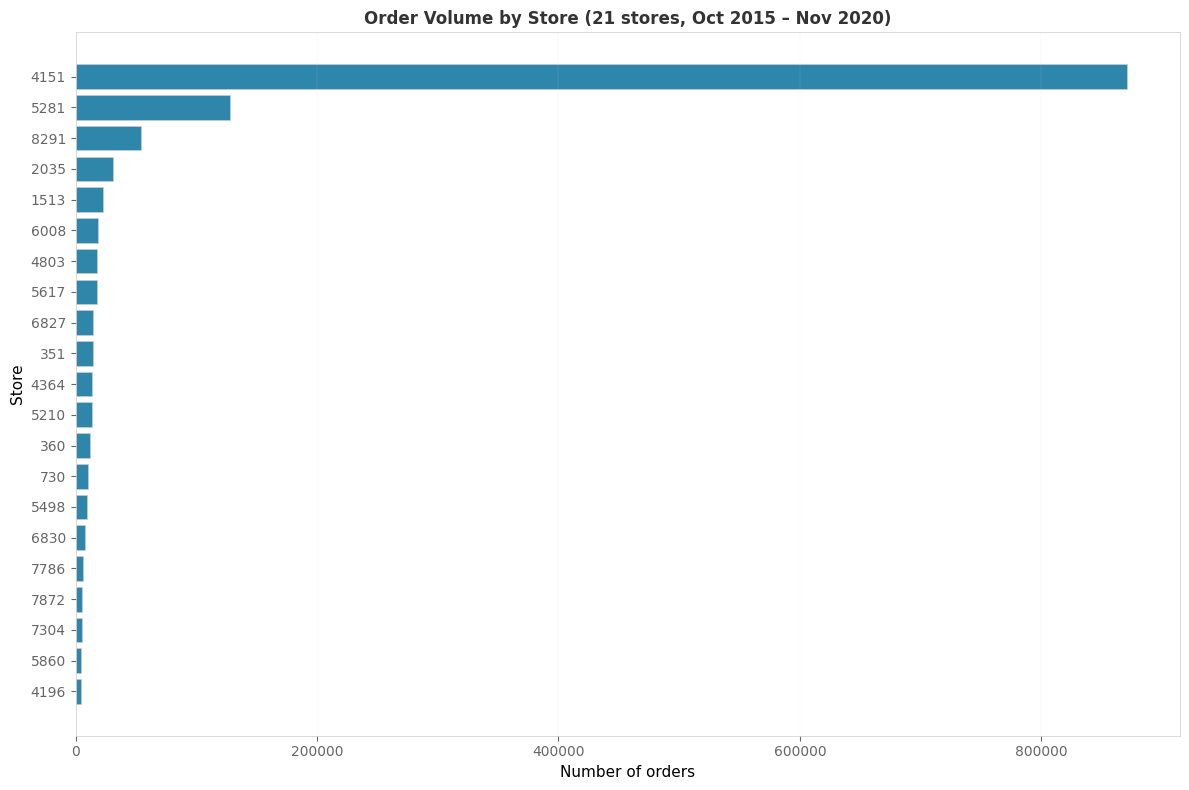

  ✓ Saved: charts/2_5_1_orders_by_store.png


In [55]:
fig, ax = plt.subplots(figsize=(12, 8))
orders_sorted = store_df.sort_values("orders", ascending=True)
ax.barh(orders_sorted["id_store"].astype(str), orders_sorted["orders"], color='#2E86AB', edgecolor='#cccccc', linewidth=0.5)
ax.set_xlabel("Number of orders")
ax.set_ylabel("Store")
ax.set_title("Order Volume by Store (21 stores, Oct 2015 – Nov 2020)", fontweight='bold')
ax.xaxis.grid(True, alpha=0.3)
save_and_show(fig, "2_5_1_orders_by_store.png")

### Chart 2: Average Order Value by Store

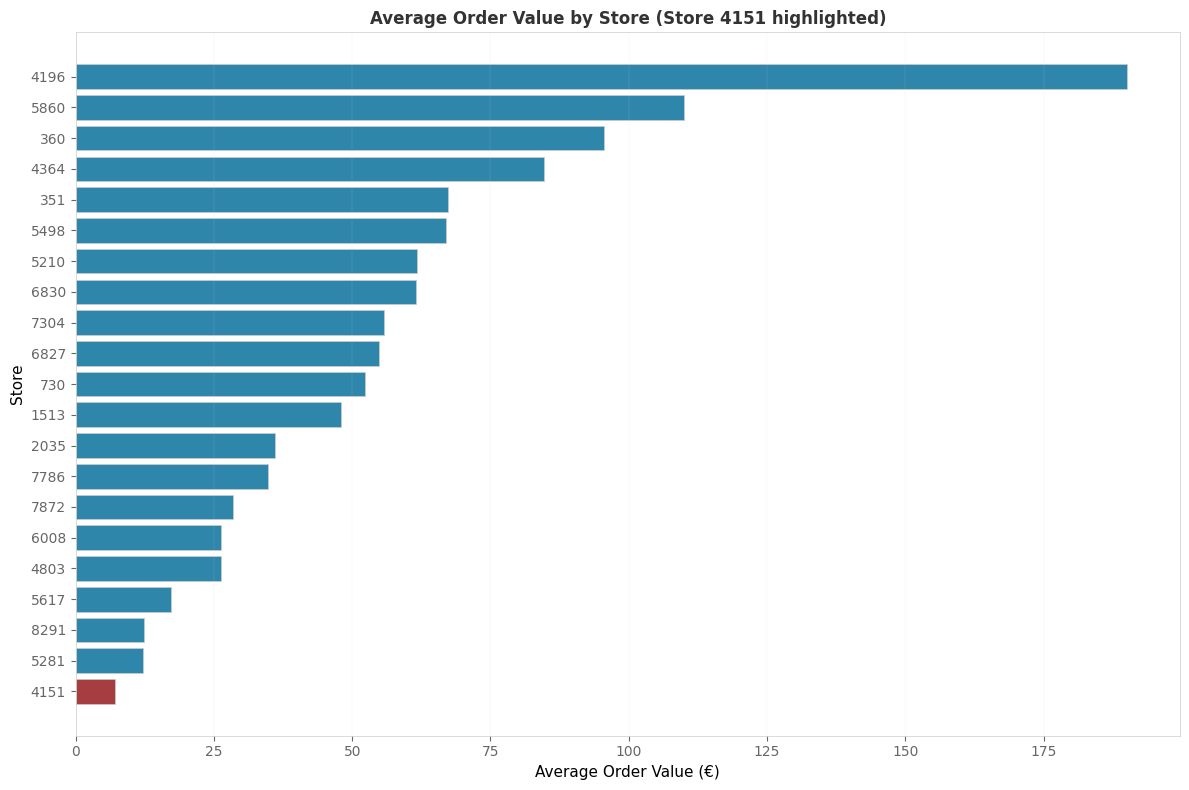

  ✓ Saved: charts/2_5_1_aov_by_store.png


In [56]:
fig, ax = plt.subplots(figsize=(12, 8))
aov_sorted = store_df.sort_values("avg_order_value", ascending=True)
colors = ['#A63D40' if sid == 4151 else '#2E86AB' for sid in aov_sorted['id_store']]
ax.barh(aov_sorted["id_store"].astype(str), aov_sorted["avg_order_value"], color=colors, edgecolor='#cccccc', linewidth=0.5)
ax.set_xlabel("Average Order Value (€)")
ax.set_ylabel("Store")
ax.set_title("Average Order Value by Store (Store 4151 highlighted)", fontweight='bold')
ax.xaxis.grid(True, alpha=0.3)
save_and_show(fig, "2_5_1_aov_by_store.png")

### Chart 3: Store 4151 vs Other Stores

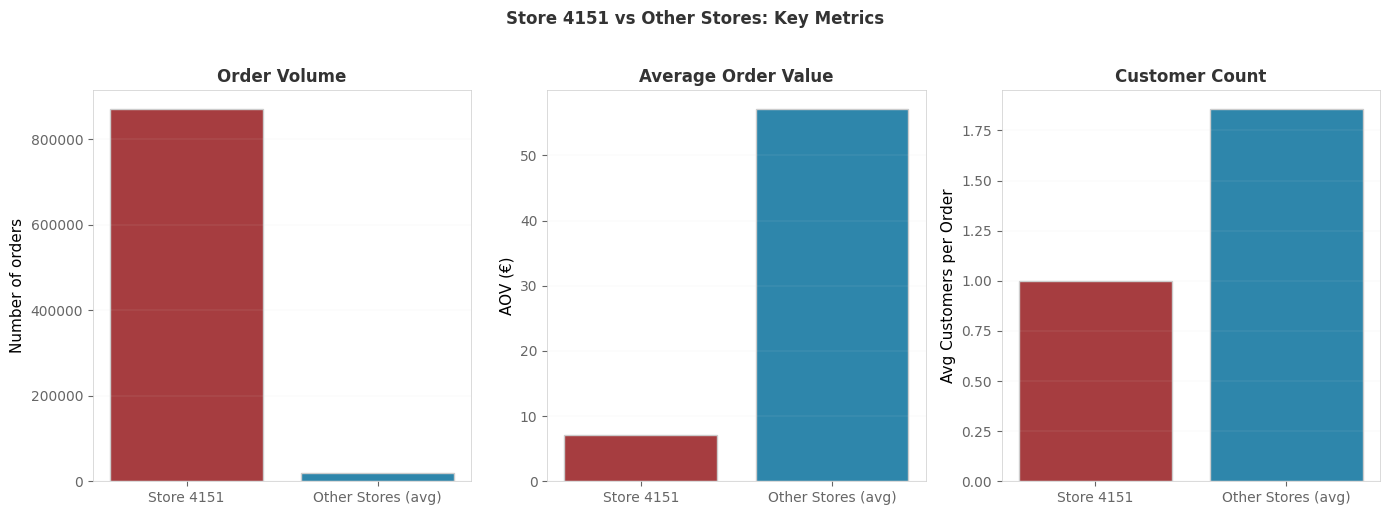

  ✓ Saved: charts/2_5_1_store_4151_vs_others.png


In [57]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

ax = axes[0]
ax.bar(['Store 4151', 'Other Stores (avg)'], [store_4151['orders'], other_stores['orders'].mean()], color=['#A63D40', '#2E86AB'], edgecolor='#cccccc')
ax.set_ylabel("Number of orders")
ax.set_title("Order Volume", fontweight='bold')
ax.yaxis.grid(True, alpha=0.3)

ax = axes[1]
ax.bar(['Store 4151', 'Other Stores (avg)'], [store_4151['avg_order_value'], other_stores['avg_order_value'].mean()], color=['#A63D40', '#2E86AB'], edgecolor='#cccccc')
ax.set_ylabel("AOV (€)")
ax.set_title("Average Order Value", fontweight='bold')
ax.yaxis.grid(True, alpha=0.3)

ax = axes[2]
ax.bar(['Store 4151', 'Other Stores (avg)'], [store_4151['avg_customers'], other_stores['avg_customers'].mean()], color=['#A63D40', '#2E86AB'], edgecolor='#cccccc')
ax.set_ylabel("Avg Customers per Order")
ax.set_title("Customer Count", fontweight='bold')
ax.yaxis.grid(True, alpha=0.3)

plt.suptitle("Store 4151 vs Other Stores: Key Metrics", fontweight='bold', y=1.02)
save_and_show(fig, "2_5_1_store_4151_vs_others.png")

### Key Findings

- **Store 4151 dominates volume:** 871,415 orders (68.02% of total)
- **Store 4151 has lowest AOV:** €7.03 vs €57.11 average for other stores
- **High-volume ≠ high-value:** The highest-volume store has the lowest average order value
- **Implication:** Store composition strongly affects aggregate metrics; store-level analysis is essential

Store 4151 also has a different product mix (high volumes in PRESSION, WINES & CHAMPAGNES, SOFT, STRONG ALCOHOLS) and should not be treated as a typical store when interpreting overall trends.

---
## 2.5.2 Temporal Behaviour

### Context

Transaction activity shows clear variation over time — yearly, weekly, and hourly. Understanding these patterns is crucial for demand forecasting and operational planning.

### Key Questions

- How has order volume evolved over the observation period?
- Are there recurring weekly or hourly patterns?
- Do volume and value follow the same temporal patterns?

### Why This Matters

Temporal patterns provide analytical signals for forecasting and reveal operational insights about customer behaviour.

In [58]:
query = """
SELECT EXTRACT(YEAR FROM date_opened) AS year, COUNT(*) AS orders, ROUND(AVG(m_cached_price), 2) AS avg_order_value
FROM `le-wagon-da-502302.tiller.order_data`
WHERE date_opened IS NOT NULL
GROUP BY year
ORDER BY year
"""
temporal_yearly = run_query(query)
temporal_yearly

,year,orders,avg_order_value
0,2015,890,58.05
1,2016,20129,48.76
2,2017,61003,29.57
3,2018,428713,14.02
4,2019,564123,14.06
5,2020,206290,16.97


### Chart 4: Long-term Trends (Yearly)

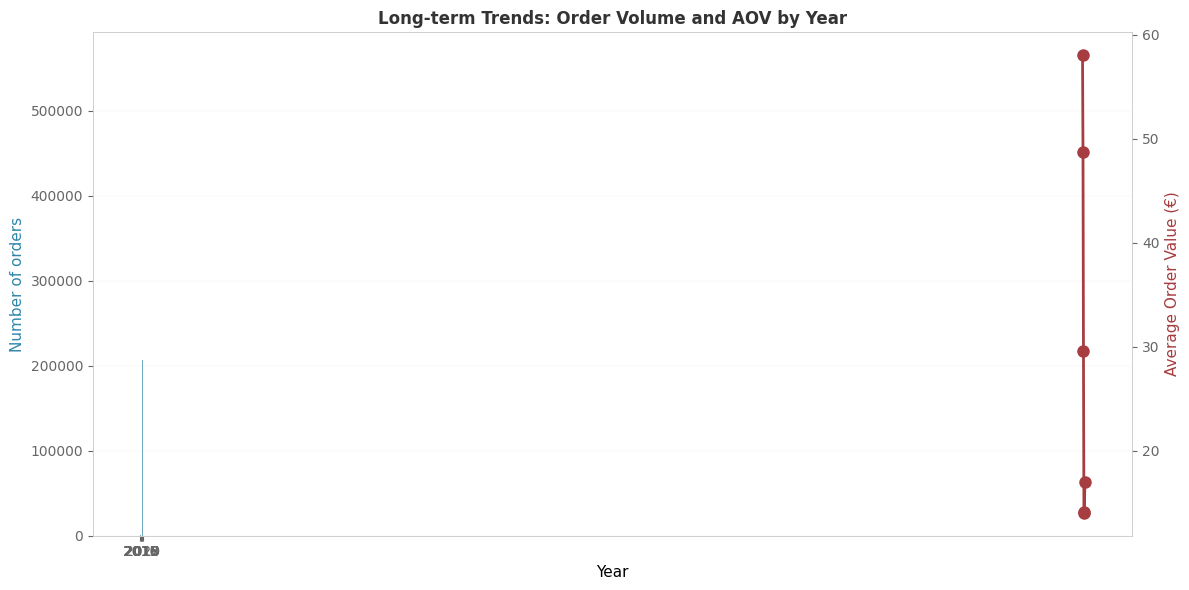

  ✓ Saved: charts/2_5_2_yearly_trend.png


In [59]:
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(temporal_yearly['year'].astype(str), temporal_yearly['orders'], color='#2E86AB', alpha=0.7)
ax1.set_xlabel("Year")
ax1.set_ylabel("Number of orders", color='#2E86AB')
ax1.set_title("Long-term Trends: Order Volume and AOV by Year", fontweight='bold')
ax1.yaxis.grid(True, alpha=0.3)
ax2 = ax1.twinx()
ax2.plot(temporal_yearly['year'], temporal_yearly['avg_order_value'], color='#A63D40', marker='o', linewidth=2, markersize=8)
ax2.set_ylabel("Average Order Value (€)", color='#A63D40')
save_and_show(fig, "2_5_2_yearly_trend.png")

In [60]:
query = """
SELECT EXTRACT(DAYOFWEEK FROM date_opened) AS day_num, FORMAT_DATE('%A', date_opened) AS day_name, COUNT(*) AS orders, ROUND(AVG(m_cached_price), 2) AS avg_order_value
FROM `le-wagon-da-502302.tiller.order_data`
WHERE date_opened IS NOT NULL
GROUP BY day_num, day_name
ORDER BY day_num
"""
temporal_weekly = run_query(query)
temporal_weekly

,day_num,day_name,orders,avg_order_value
0,1,Sunday,168682,10.38
1,2,Monday,46079,27.44
2,3,Tuesday,68383,32.27
3,4,Wednesday,194719,16.34
4,5,Thursday,223696,16.09
5,6,Friday,275851,15.22
6,7,Saturday,303738,13.44


### Chart 5: Weekly Patterns

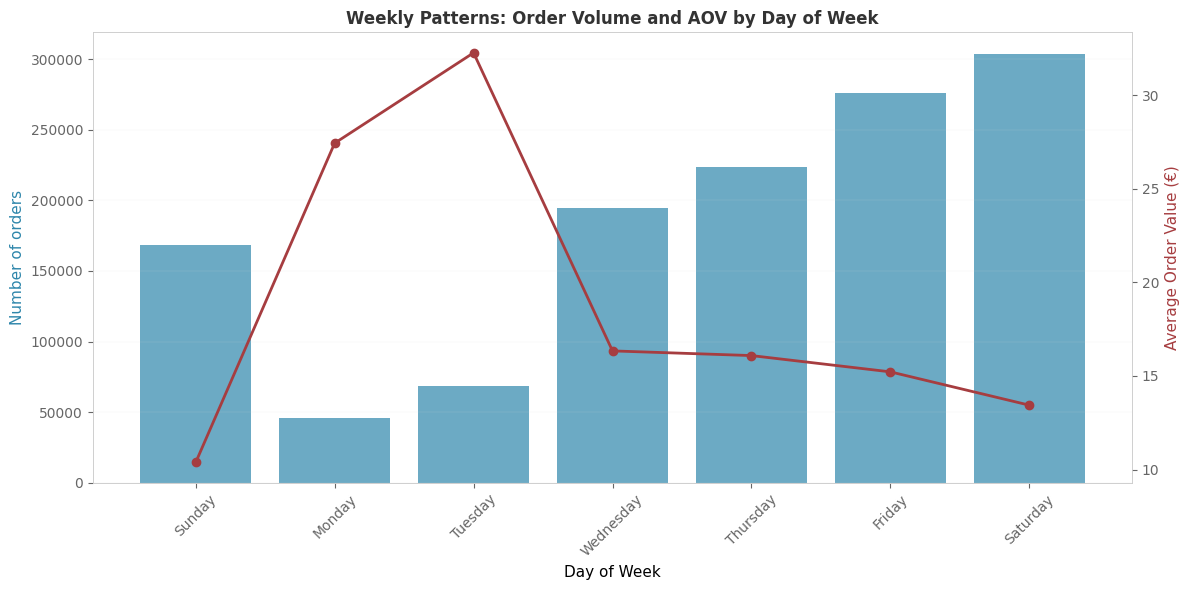

  ✓ Saved: charts/2_5_2_weekly_pattern.png


In [61]:
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(temporal_weekly['day_name'], temporal_weekly['orders'], color='#2E86AB', alpha=0.7)
ax1.set_xlabel("Day of Week")
ax1.set_ylabel("Number of orders", color='#2E86AB')
ax1.set_title("Weekly Patterns: Order Volume and AOV by Day of Week", fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.grid(True, alpha=0.3)
ax2 = ax1.twinx()
ax2.plot(range(7), temporal_weekly['avg_order_value'], color='#A63D40', marker='o', linewidth=2)
ax2.set_ylabel("Average Order Value (€)", color='#A63D40')
save_and_show(fig, "2_5_2_weekly_pattern.png")

In [62]:
query = """
SELECT EXTRACT(HOUR FROM date_opened) AS hour, COUNT(*) AS orders, ROUND(AVG(m_cached_price), 2) AS avg_order_value
FROM `le-wagon-da-502302.tiller.order_data`
WHERE date_opened IS NOT NULL
GROUP BY hour
ORDER BY hour
"""
temporal_hourly = run_query(query)
temporal_hourly

,hour,orders,avg_order_value
0,0,1533,37.16
1,1,623,54.86
2,2,175,30.55
3,3,150,42.08
4,4,89,52.95
5,5,88,52.27
6,6,635,12.21
7,7,5753,9.87
8,8,12564,12.49
9,9,18113,14.96


### Chart 6: Hourly Patterns

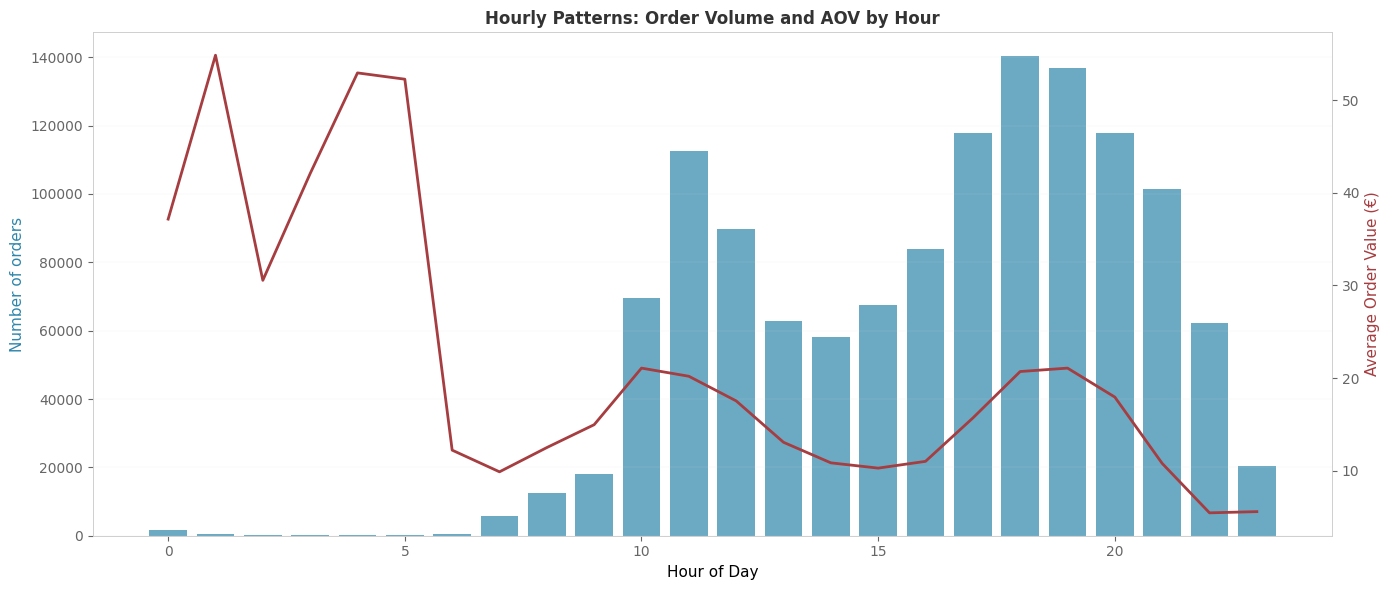

  ✓ Saved: charts/2_5_2_hourly_pattern.png


In [63]:
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.bar(temporal_hourly['hour'], temporal_hourly['orders'], color='#2E86AB', alpha=0.7)
ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Number of orders", color='#2E86AB')
ax1.set_title("Hourly Patterns: Order Volume and AOV by Hour", fontweight='bold')
ax1.yaxis.grid(True, alpha=0.3)
ax2 = ax1.twinx()
ax2.plot(temporal_hourly['hour'], temporal_hourly['avg_order_value'], color='#A63D40', linewidth=2)
ax2.set_ylabel("Average Order Value (€)", color='#A63D40')
save_and_show(fig, "2_5_2_hourly_pattern.png")

### Key Findings

- **Long-term trend:** Order volume increased substantially 2015→2019; AOV decreased (influenced by changing store composition and Store 4151 growth)
- **Weekly pattern:** Sunday has highest volume (168,682 orders); weekday AOV varies independently from volume
- **Hourly pattern:** Clear peaks during lunch (11:00-13:00) and dinner (18:00-20:00); different stores show different operating patterns
- **Implication:** Time-based features provide meaningful analytical signals for forecasting and operational planning

---
## 2.5.3 Product and Category Behaviour

### Context

The order-line data contains **12,145 unique products** and **456 raw categories** (438 translated). Product activity is concentrated in relatively few categories, but taxonomy inconsistencies exist.

### Key Questions

- Which categories contribute most to order-line value?
- How concentrated is product activity?
- Are there taxonomy issues that would affect product analysis?

### Why This Matters

Understanding product mix and category concentration helps identify whether product/basket analysis is feasible and valuable.

In [64]:
query = """
SELECT dim_category, COUNT(*) AS order_lines, ROUND(SUM(m_total_price_inc_vat), 2) AS total_value
FROM `le-wagon-da-502302.tiller.order_line`
WHERE dim_category IS NOT NULL
GROUP BY dim_category
ORDER BY order_lines DESC
LIMIT 15
"""
category_dist = run_query(query)
category_dist

,dim_category,order_lines,total_value
0,CONSIGNE,1278896,-165030.00
1,PRESSION,513254,3619901.30
2,SOFT,236536,733093.25
3,EXPRESSIONS ESPRESSO,124811,504165.90
4,VINS & CHAMPAGNES,91470,741491.60
5,BIERES & CIDRES BOUTEILLES,73569,400305.05
6,Plats,66131,1191314.65
7,VARIOUS,57484,9340.06
8,ALCOOLS FORTS,55913,508200.50
9,Desserts,49365,333372.55


### Chart 7: Top Categories by Order Lines

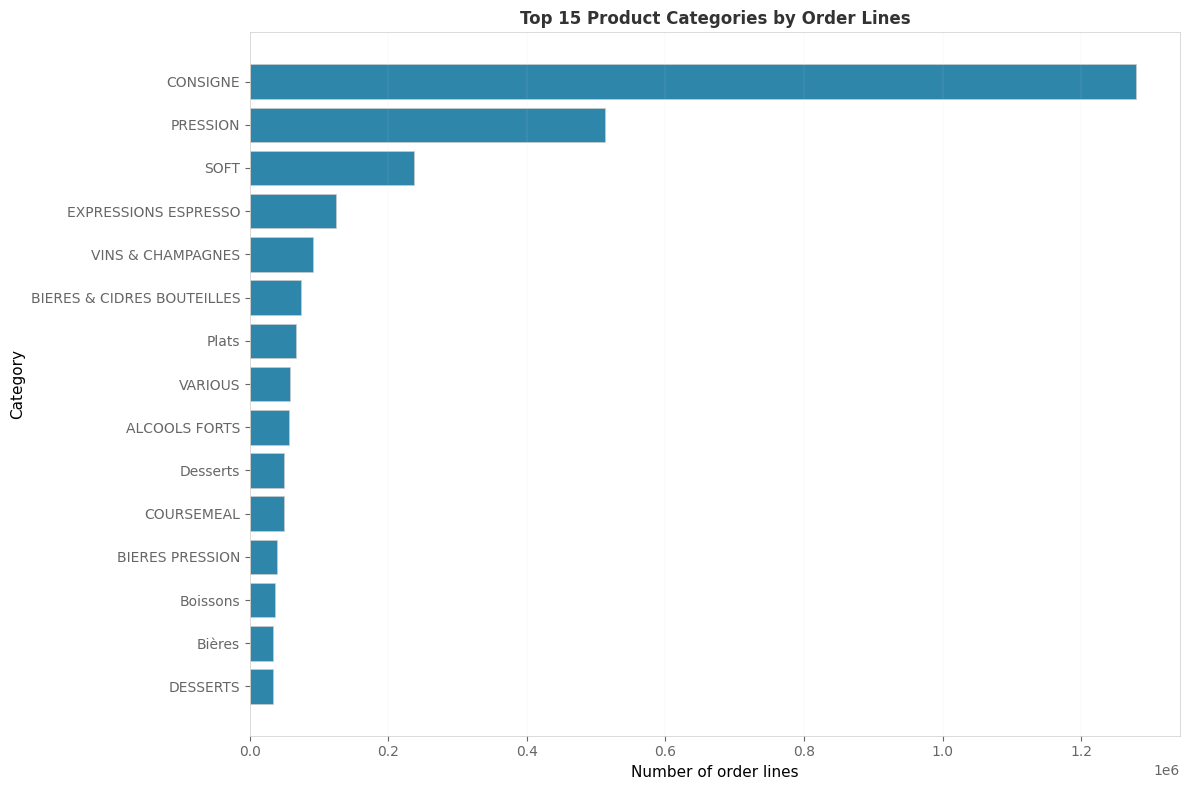

  ✓ Saved: charts/2_5_3_top_categories.png


In [65]:
fig, ax = plt.subplots(figsize=(12, 8))
cat_sorted = category_dist.sort_values("order_lines", ascending=True)
ax.barh(cat_sorted["dim_category"], cat_sorted["order_lines"], color='#2E86AB', edgecolor='#cccccc', linewidth=0.5)
ax.set_xlabel("Number of order lines")
ax.set_ylabel("Category")
ax.set_title("Top 15 Product Categories by Order Lines", fontweight='bold')
ax.xaxis.grid(True, alpha=0.3)
save_and_show(fig, "2_5_3_top_categories.png")

In [66]:
query = """
SELECT dim_category, COUNT(*) AS order_lines, ROUND(SUM(m_total_price_inc_vat), 2) AS total_value
FROM `le-wagon-da-502302.tiller.order_line`
WHERE dim_category IS NOT NULL
GROUP BY dim_category
ORDER BY total_value DESC
LIMIT 15
"""
category_value = run_query(query)
category_value

,dim_category,order_lines,total_value
0,PRESSION,513254,3619901.30
1,Plats,66131,1191314.65
2,COURSEMEAL,48876,793676.40
3,VINS & CHAMPAGNES,91470,741491.60
4,SOFT,236536,733093.25
5,PLATS,29588,544764.44
6,ALCOOLS FORTS,55913,508200.50
7,EXPRESSIONS ESPRESSO,124811,504165.90
8,vente directe,18888,459094.88
9,BIERES & CIDRES BOUTEILLES,73569,400305.05


### Chart 8: Top Categories by Value

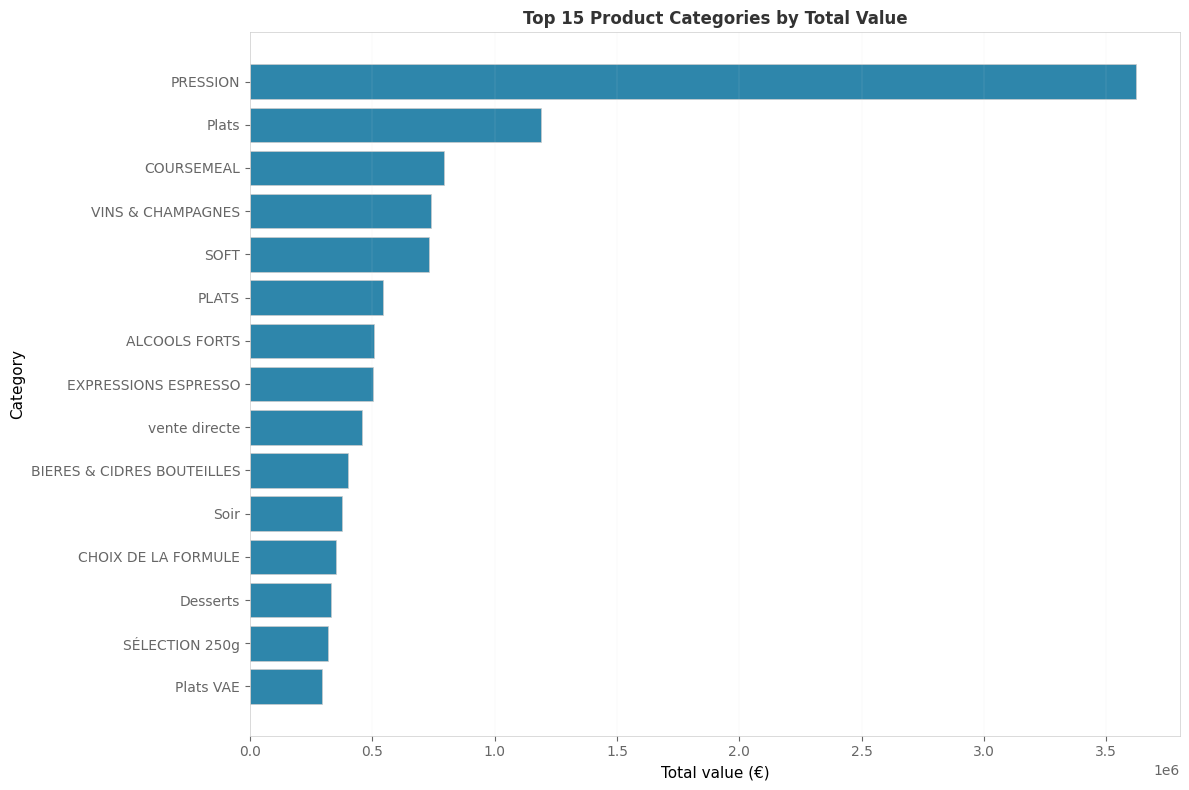

  ✓ Saved: charts/2_5_3_top_categories_value.png


In [67]:
fig, ax = plt.subplots(figsize=(12, 8))
val_sorted = category_value.sort_values("total_value", ascending=True)
ax.barh(val_sorted["dim_category"], val_sorted["total_value"], color='#2E86AB', edgecolor='#cccccc', linewidth=0.5)
ax.set_xlabel("Total value (€)")
ax.set_ylabel("Category")
ax.set_title("Top 15 Product Categories by Total Value", fontweight='bold')
ax.xaxis.grid(True, alpha=0.3)
save_and_show(fig, "2_5_3_top_categories_value.png")

### Key Findings

- **High concentration:** PRESSION represents 17.8% of total order-line value
- **Taxonomy issues:** 
  - CONSIGNE (raw) maps to ORDER — 1,278,896 order lines (technical, not commercial)
  - Multiple language variants and spelling inconsistencies exist
- **12,145 products, 456 categories:** Substantial analytical potential but requires taxonomy validation
- **Implication:** Product analysis is feasible, but deeper basket analysis would require additional taxonomy cleaning

---
## 2.5.4 Transaction and Customer Economics

### Context

Order value varies substantially based on transaction composition. This section examines how the number of customers and items per order relates to order value.

### Key Questions

- How does order value vary with the number of customers?
- How does order value vary with the number of items?
- Are these relationships associations or causal?

### Why This Matters

Understanding what drives higher-value transactions can inform operational strategies and analytical priorities.

In [68]:
query = """
SELECT CASE
    WHEN m_nb_customer = 1 THEN '1 customer'
    WHEN m_nb_customer = 2 THEN '2 customers'
    WHEN m_nb_customer BETWEEN 3 AND 4 THEN '3-4 customers'
    ELSE '5+ customers'
END AS customer_segment, COUNT(*) AS orders, ROUND(AVG(m_cached_price), 2) AS avg_order_value
FROM `le-wagon-da-502302.tiller.order_data`
WHERE m_nb_customer IS NOT NULL
GROUP BY customer_segment
ORDER BY MIN(m_nb_customer)
"""
customers_grouped = run_query(query)
customers_grouped

,customer_segment,orders,avg_order_value
0,5+ customers,29206,73.55
1,1 customer,1075499,9.96
2,2 customers,146588,32.25
3,3-4 customers,29855,90.12


### Chart 9: Customers per Order

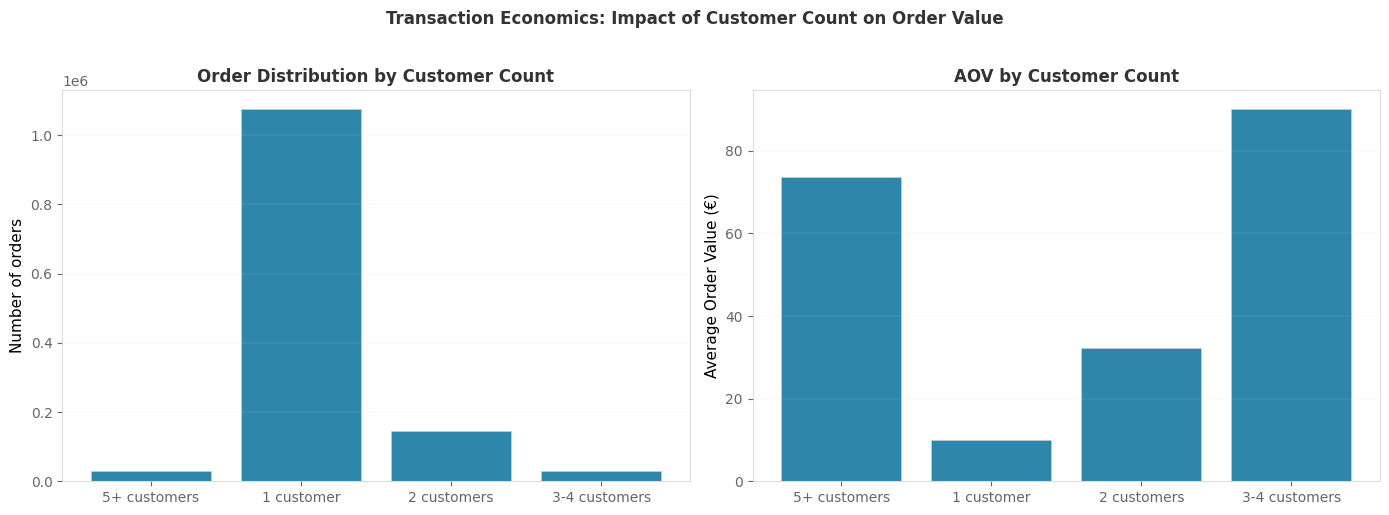

  ✓ Saved: charts/2_5_4_customers_per_order.png


In [69]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(customers_grouped['customer_segment'], customers_grouped['orders'], color='#2E86AB', edgecolor='#cccccc', linewidth=0.5)
axes[0].set_ylabel("Number of orders")
axes[0].set_title("Order Distribution by Customer Count", fontweight='bold')
axes[0].yaxis.grid(True, alpha=0.3)

axes[1].bar(customers_grouped['customer_segment'], customers_grouped['avg_order_value'], color='#2E86AB', edgecolor='#cccccc', linewidth=0.5)
axes[1].set_ylabel("Average Order Value (€)")
axes[1].set_title("AOV by Customer Count", fontweight='bold')
axes[1].yaxis.grid(True, alpha=0.3)

plt.suptitle("Transaction Economics: Impact of Customer Count on Order Value", fontweight='bold', y=1.02)
save_and_show(fig, "2_5_4_customers_per_order.png")

In [70]:
query = """
SELECT CASE
    WHEN items_per_order BETWEEN 1 AND 2 THEN '1-2 items'
    WHEN items_per_order BETWEEN 3 AND 5 THEN '3-5 items'
    WHEN items_per_order BETWEEN 6 AND 10 THEN '6-10 items'
    ELSE '11+ items'
END AS item_segment, COUNT(*) AS orders, ROUND(AVG(order_value), 2) AS avg_order_value
FROM (
    SELECT od.id_order, od.m_cached_price AS order_value, COUNT(ol.id_order_line) AS items_per_order
    FROM `le-wagon-da-502302.tiller.order_data` od
    JOIN `le-wagon-da-502302.tiller.order_line` ol ON od.id_order = ol.id_order
    GROUP BY od.id_order, od.m_cached_price
)
GROUP BY item_segment
ORDER BY MIN(items_per_order)
"""
items_grouped = run_query(query)
items_grouped

,item_segment,orders,avg_order_value
0,1-2 items,754111,6.96
1,3-5 items,369994,16.92
2,6-10 items,124235,42.71
3,11+ items,31150,111.24


### Chart 10: Items per Order

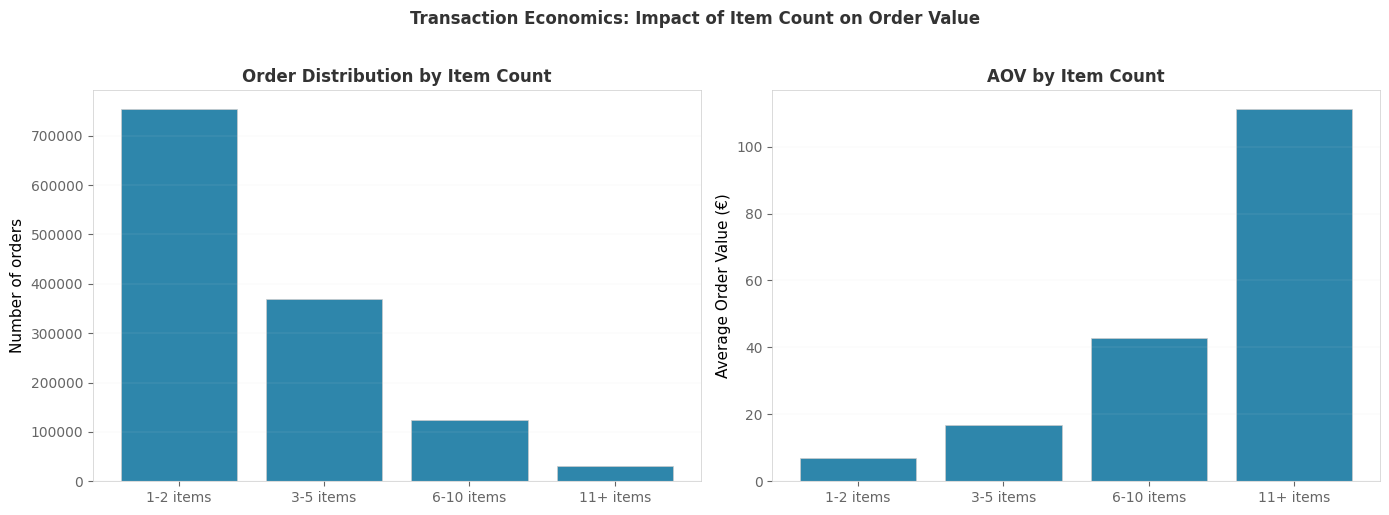

  ✓ Saved: charts/2_5_4_items_per_order.png


In [71]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(items_grouped['item_segment'], items_grouped['orders'], color='#2E86AB', edgecolor='#cccccc', linewidth=0.5)
axes[0].set_ylabel("Number of orders")
axes[0].set_title("Order Distribution by Item Count", fontweight='bold')
axes[0].yaxis.grid(True, alpha=0.3)

axes[1].bar(items_grouped['item_segment'], items_grouped['avg_order_value'], color='#2E86AB', edgecolor='#cccccc', linewidth=0.5)
axes[1].set_ylabel("Average Order Value (€)")
axes[1].set_title("AOV by Item Count", fontweight='bold')
axes[1].yaxis.grid(True, alpha=0.3)

plt.suptitle("Transaction Economics: Impact of Item Count on Order Value", fontweight='bold', y=1.02)
save_and_show(fig, "2_5_4_items_per_order.png")

### Key Findings

- **Strong positive association:** More customers/items → substantially higher order values
- **Customer segments:** €9.96 (1 cust) → €32.25 (2) → €90.12 (3-4) → €73.55 (5+)
- **Item segments:** €6.96 (1-2 items) → €16.92 (3-5) → €42.71 (6-10) → €111.24 (11+)
- **Important:** These are **associations, not causal relationships**
- **Implication:** Transaction composition provides meaningful analytical signals for understanding order value drivers

---
## 2.5.5 Payment and Operational Behaviour

### Context

The dataset contains information about payment methods, order sources, and operational dimensions. This section examines payment behaviour and identifies financial anomalies.

### Key Questions

- What payment methods are most common?
- How do order sources differ in volume and value?
- What proportion of transactions have negative values?

### Why This Matters

Payment behaviour provides contextual understanding; financial anomalies require careful interpretation in analysis.

In [72]:
query = """
SELECT dim_type, COUNT(*) AS payments, ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM `le-wagon-da-502302.tiller.payment_data`), 2) AS pct_of_total
FROM `le-wagon-da-502302.tiller.payment_data`
WHERE dim_type IS NOT NULL
GROUP BY dim_type
ORDER BY payments DESC
"""
payment_dist = run_query(query)
payment_dist.head(10)

,dim_type,payments,pct_of_total
0,CARD,728607,51.92
1,CASH,615195,43.84
2,TICKET_RESTAURANT,36557,2.61
3,FIVORY,7436,0.53
4,CREDIT_NOTE,5574,0.40
5,CB_Sans_Contact,3832,0.27
6,SUMUP,1382,0.10
7,BANK_CHECK,1099,0.08
8,VOUCHER,963,0.07
9,AMERICAN_EXPRESS,772,0.06


### Chart 11: Payment Type Distribution

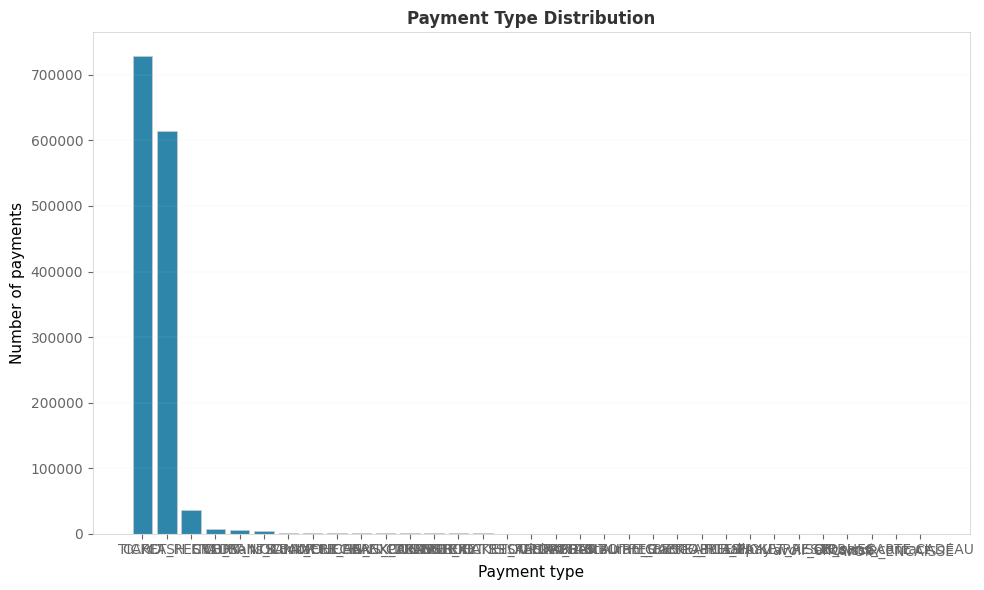

  ✓ Saved: charts/2_5_5_payment_types.png


In [73]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(payment_dist['dim_type'], payment_dist['payments'], color='#2E86AB', edgecolor='#cccccc', linewidth=0.5)
ax.set_ylabel("Number of payments")
ax.set_xlabel("Payment type")
ax.set_title("Payment Type Distribution", fontweight='bold')
ax.yaxis.grid(True, alpha=0.3)
save_and_show(fig, "2_5_5_payment_types.png")

In [74]:
query = """
SELECT dim_source, COUNT(*) AS orders, ROUND(AVG(m_cached_price), 2) AS avg_order_value
FROM `le-wagon-da-502302.tiller.order_data`
WHERE dim_source IS NOT NULL
GROUP BY dim_source
ORDER BY orders DESC
"""
order_source = run_query(query)
order_source

,dim_source,orders,avg_order_value
0,Tiller iPAD,1122780,14.17
1,tiller-order,100879,23.47
2,LAFOURCHETTE,715,9.27
3,Tiller iPod,9,39.44
4,ZENCHEF,6,83.37


### Chart 12: Order Sources

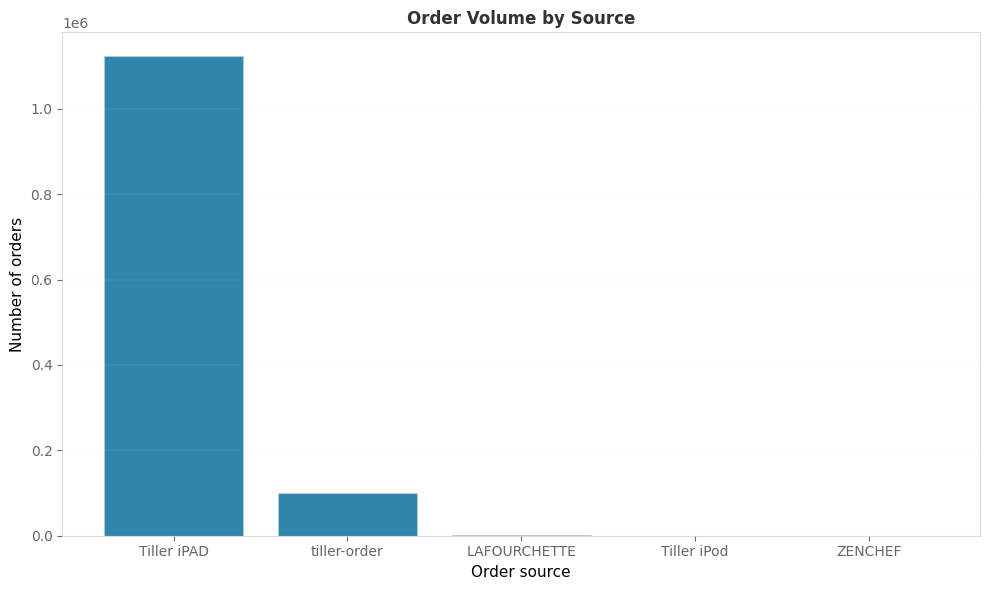

  ✓ Saved: charts/2_5_5_order_sources.png


In [75]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(order_source['dim_source'], order_source['orders'], color='#2E86AB', edgecolor='#cccccc', linewidth=0.5)
ax.set_ylabel("Number of orders")
ax.set_xlabel("Order source")
ax.set_title("Order Volume by Source", fontweight='bold')
ax.yaxis.grid(True, alpha=0.3)
save_and_show(fig, "2_5_5_order_sources.png")

In [76]:
# Financial anomalies
anomalies_orders = run_query("SELECT 'Orders' AS metric, SUM(CASE WHEN m_cached_price < 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS pct FROM `le-wagon-da-502302.tiller.order_data`")
anomalies_lines = run_query("SELECT 'Order Lines' AS metric, SUM(CASE WHEN m_total_price_inc_vat < 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS pct FROM `le-wagon-da-502302.tiller.order_line`")
anomalies_payments = run_query("SELECT 'Payments' AS metric, SUM(CASE WHEN m_amount < 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS pct FROM `le-wagon-da-502302.tiller.payment_data`")

print(f"Negative order values: {anomalies_orders['pct'].iloc[0]:.2f}%")
print(f"Negative order-line values: {anomalies_lines['pct'].iloc[0]:.2f}%")
print(f"Negative payment amounts: {anomalies_payments['pct'].iloc[0]:.2f}%")

Negative order values: 20.56%
Negative order-line values: 17.12%
Negative payment amounts: 20.48%


### Chart 13: Financial Anomalies

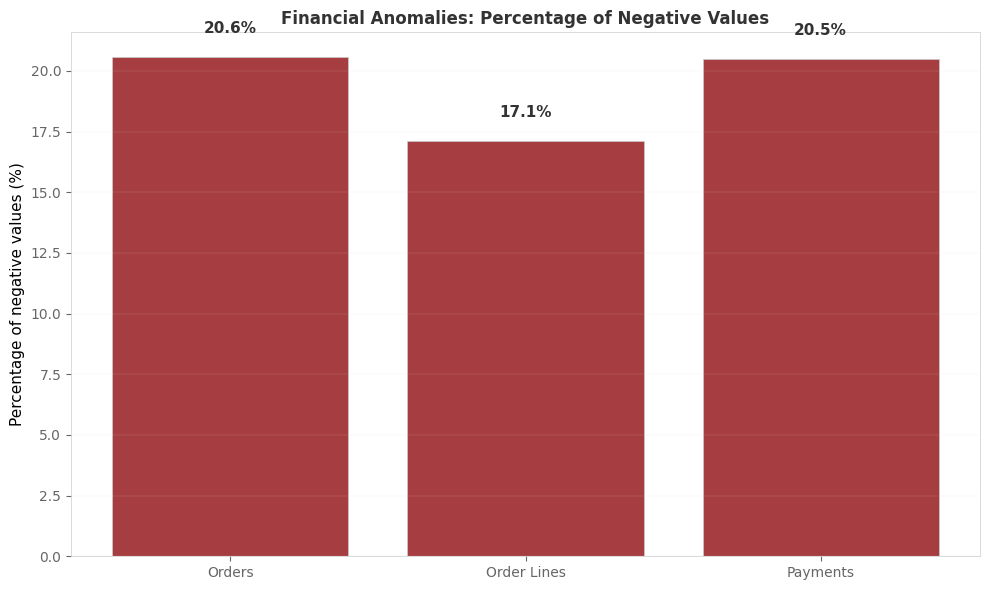

  ✓ Saved: charts/2_5_5_financial_anomalies.png


In [77]:
fig, ax = plt.subplots(figsize=(10, 6))
metrics = ['Orders', 'Order Lines', 'Payments']
pct_negative = [anomalies_orders['pct'].iloc[0], anomalies_lines['pct'].iloc[0], anomalies_payments['pct'].iloc[0]]
ax.bar(metrics, pct_negative, color='#A63D40', edgecolor='#cccccc', linewidth=0.5)
ax.set_ylabel("Percentage of negative values (%)")
ax.set_title("Financial Anomalies: Percentage of Negative Values", fontweight='bold')
ax.yaxis.grid(True, alpha=0.3)
for i, v in enumerate(pct_negative):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold', fontsize=11)
save_and_show(fig, "2_5_5_financial_anomalies.png")

### Key Findings

- **Payment concentration:** CARD (51.92%) and CASH (43.84%) dominate; other methods are marginal
- **Order sources:** Tiller iPAD (1,122,780 orders, €14.17 AOV) is primary; tiller-order (100,879, €23.47) has higher AOV
- **Financial anomalies:** Substantial negative values across all tables:
  - Orders: 20.56%
  - Order lines: 17.12%
  - Payments: 20.48%
- **Important:** Negative values are not automatically errors; business meaning is undefined in source data
- **Implication:** Payment behaviour is useful context; financial anomalies require careful interpretation

---
## Phase 2.5 Summary

### Key Findings

| Dimension | Key Insight |
|-----------|-------------|
| **Store-level** | Store 4151 = 68% of orders but lowest AOV (€7.03); aggregate metrics strongly influenced by store composition |
| **Temporal** | Clear yearly, weekly, hourly patterns; Sunday highest volume; lunch/dinner peaks |
| **Product/Category** | High concentration (PRESSION 17.8%); taxonomy requires validation before deep basket analysis |
| **Transaction Economics** | Strong positive association: more customers/items → higher AOV (€6.96 → €111.24) |
| **Payment/Operational** | CARD 52%, CASH 44%; 20%+ negative values (not necessarily errors) |